## Introductory Machine Learning: Assignment 5

### Problem 1: Gutenberg Books Language Models (15 points)

For this problem you will process books from the [Project Gutenberg](https://www.gutenberg.org/) site which is a public respository of large numbers of books that are in the public domain. You'll build *character-based* (as opposed to word-based) language models on one book, and predict the letters of the other book using the model.


In [45]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plots
%matplotlib inline

The following helper function `read_url` reads in the text at the given url, and then uses some 
[regular expressions](https://www.w3schools.com/python/python_regex.asp) to process the book, removing 
everything but the letters a-z, space and period.

In [46]:
from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

def process_text(text):
    text = re.sub('[^a-zA-z .]', '', text.lower())
    return re.sub('[\[\]\_]', '', text)


<img src="https://www.gutenberg.org/cache/epub/76/pg76.cover.medium.jpg" width="110" align="top">

The online book for "Adventures of Huckleberry Finn," by Mark Twain, is [here](https://www.gutenberg.org/ebooks/76).
From this web site you can see various metadata for the book as well as the [link the text itself](https://www.gutenberg.org/files/76/76-0.txt), which is [https://www.gutenberg.org/files/76/76-0.txt](https://www.gutenberg.org/files/76/76-0.txt)

The book for Mark Twain's "A Connecticut Yankee in King Arthur's Court" is [here](https://www.gutenberg.org/ebooks/86).
In the following cell we read in both of these books, and remove all characters except a-z, space, and period.

In [47]:
huck_finn_url = 'https://www.gutenberg.org/files/76/76-0.txt'
huck_finn_text_raw = read_url(huck_finn_url)
huck_finn_text = process_text(huck_finn_text_raw)

ct_yankee_url = 'https://www.gutenberg.org/files/86/86-0.txt'
ct_yankee_text_raw = read_url(ct_yankee_url)
ct_yankee_text = process_text(ct_yankee_text_raw)


In [48]:
print("\nSample of raw text:\n")
print(huck_finn_text_raw[10000:11000])

print("\nSample of processed text:\n")
print(huck_finn_text[10000:11000])


Sample of raw text:

my old rags and my sugar-hogshead again, and was free and satisfied. But Tom Sawyer he hunted me up and said he was going to start a band of robbers, and I might join if I would go back to the widow and be respectable. So I went back. The widow she cried over me, and called me a poor lost lamb, and she called me a lot of other names, too, but she never meant no harm by it. She put me in them new clothes again, and I couldn't do nothing but sweat and sweat, and feel all cramped up. Well, then, the old thing commenced again. The widow rung a bell for supper, and you had to come to time. When you got to the table you couldn't go right to eating, but you had to wait for the widow to tuck down her head and grumble a little over the victuals, though there warn't really anything the matter with them,--that is, nothing only everything was cooked by itself. In a barrel of odds and ends it is different; things get mixed up, and the juice kind of swaps around, and the things

<img src="https://www.gutenberg.org/cache/epub/1342/pg1342.cover.medium.jpg" width="110" align="top">


The online book for "Pride and Prejudice", by Jane Austen, is [here](https://www.gutenberg.org/ebooks/1342).
And [here](https://www.gutenberg.org/ebooks/158) is the online book for Jane Austen's "Emma".  In the following cell we read in both of these books, and remove all characters except a-z, space, and period.



In [49]:
pride_and_prejudice_url = 'https://www.gutenberg.org/files/1342/1342-0.txt'
pride_and_prejudice_text_raw = read_url(pride_and_prejudice_url)
pride_and_prejudice_text = process_text(pride_and_prejudice_text_raw)


emma_url = 'https://www.gutenberg.org/files/158/158-0.txt'
emma_text_raw = read_url(emma_url)
emma_text = process_text(emma_text_raw)

In [50]:
print("\nSample of raw text:\n")
print(emma_text_raw[10000:11000])

print("\nSample of processed text:\n")
print(emma_text[10000:11000])


Sample of raw text:

all are.” Emma spared no exertions to maintain this happier flow of ideas, and hoped, by the help of backgammon, to get her father tolerably through the evening, and be attacked by no regrets but her own. The backgammon-table was placed; but a visitor immediately afterwards walked in and made it unnecessary. Mr. Knightley, a sensible man about seven or eight-and-thirty, was not only a very old and intimate friend of the family, but particularly connected with it, as the elder brother of Isabella’s husband. He lived about a mile from Highbury, was a frequent visitor, and always welcome, and at this time more welcome than usual, as coming directly from their mutual connexions in London. He had returned to a late dinner, after some days’ absence, and now walked up to Hartfield to say that all were well in Brunswick Square. It was a happy circumstance, and animated Mr. Woodhouse for some time. Mr. Knightley had a cheerful manner, which always did him good; and his man

The following cell defines some helper code. You should just run this cell; do not change any of the code. 

The first function, `ngrams`, takes some input text and a value of `n`. The function then 
iterates over the string and counts the number of occurrences of each substring of `n` characters. This is done with the very handy `Counter` class. 

We then define a class `language_model` that is a 4-gram character-based language model. The probability of the "next character" is computed using linear interpolation, as described in class.  A weight is assigned to unigrams, bigrams, trigrams, and four-grams (quadgrams?). The bigram probability that, for example, the letter `t` follows the letter `h` is the count of the bigram `ht` divided by the count of the unigram `h`. We add a little bit (1e-10) to the denominator to avoid dividing by zero. 

We return the logarithm of the probability, because this will be convenient when computing perplexities.


In [51]:
def ngrams(text, n=2):
    return Counter([text[(i-n):i] for i in np.arange(n, len(text)+1)])

class language_model:

    def __init__(self, text):
        self.one = ngrams(text, 1)
        self.two = ngrams(text, 2)
        self.three = ngrams(text, 3)
        self.four = ngrams(text, 4)
        self.weight = [0.1, 0.2, 0.3, 0.4]
        
    def set_weights(self, weights):
        self.weight = weights / np.sum(weights)
        
    def log_probability(self, gram):
        numer = [self.one[gram[3:]], 
                 self.two[gram[2:]], self.three[gram[1:]], 
                 self.four[gram[0:]]]
        denom = [sum(self.one[g] for g in self.one), 
                 self.one[gram[2:3]], self.two[gram[1:3]], 
                 self.three[gram[0:3]]]
        prob = 0
        for i in np.arange(4):
            prob += self.weight[i] * numer[i] / (denom[i]+1e-10)
        return np.log(prob)
    


### Problem 1.1

Just to be sure we understand what a character-based language model is, let's write an expression 
for the probability in an example. Suppose the language model assigns 
weight $w_1 = 0.1$ to the unigram model, weight $w_2 = 0.2$ to the bigram model, weight $w_3 = 0.3$ to the trigram model, and weight $w_4 = .4$ to the four-gram model. Note that we must have $w_1+w_2+w_3+w_4 = 1$.

Write an expression for the probability $p(\mbox{z} \,|\, \mbox{qui})$ that the letter $\mbox{z}$ follows the three letters $\mbox{qui}$. Assume that the unigram, bigram, trigram, and four-gram components are given by ratios of 
counts in the training data, as in the code above. For example, the bigram probability would be written as 

$$ \frac{\mbox{count}(iz)}{\mbox{count}(i)}$$


$$
p(z|qui) = 0.1 \cdot \frac{count(z)}{N} + 0.2 \cdot \frac{count(iz)}{count(i)} + 0.3 \cdot \frac{count(uiz)}{count(ui)} + 0.4 \cdot \frac{count(quiz)}{count(qui)}
$$

With N the total amount of characters in the document.

Now, the cell below constructs two language models, one on the text of Jane Austen's "Emma", the other on 
the text of Mark Twain's "Huckleberry Finn". 

In [52]:
emma_lm = language_model(emma_text)
huck_finn_lm = language_model(huck_finn_text)

### Problem 1.2

In this sub-problem, your job is to write a function that takes a language model `lm`, and a text string `text`, and computes the perplexity of the language model on the text. 

In [53]:
def compute_perplexity(text, lm):
    n = len(text)
    log_prob_sum = 0
    
    for i in np.arange(3,n):
        text_piece = text[(i-3):(i+1)]
        log_prob_sum += lm.log_probability(text_piece)
    
    log_prob_mean = log_prob_sum / (n-3)
    perplex = np.exp(-log_prob_mean)
    return perplex 


### Problem 1.3 

To test your implementation of the perplexity function, evaluate the followign cell. This 
computes the perplexity of the "Emma" language model on all four of the books: "Emma", "Pride and Prejudice", "Huckleberry Finn", and "Connecticut Yankee". For this problem, you will be graded on whether or not you get the correct four numbers for each of these perplexities.

In [54]:
hf_perp = compute_perplexity(huck_finn_text, emma_lm)
ct_perp = compute_perplexity(ct_yankee_text, emma_lm)
pp_perp = compute_perplexity(pride_and_prejudice_text, emma_lm)
em_perp = compute_perplexity(emma_text, emma_lm)

print("Perplexity on Huckleberry Finn: %.2f" % hf_perp)
print("Perplexity on Connecticut Yankee: %.2f" % ct_perp)
print("Perplexity on Pride and Prejudice: %.2f" % pp_perp)
print("Perplexity on Emma: %.2f" % em_perp)

Perplexity on Huckleberry Finn: 6.42
Perplexity on Connecticut Yankee: 6.18
Perplexity on Pride and Prejudice: 5.49
Perplexity on Emma: 5.11


### Problem 1.4 

Now, interpret your results above. Explain the meaning of perplexity for a character-based language model. Which book has the lowest perpexity? Why is this? Which book has the second smallest perplexity? Does this make sense? Explain. 



The perplexity is a measure to quantify how "good" a language model is, it is in this case (for a character based language model) defined as:

$$
Perplexity(\theta) = \left( \frac{1}{p_{\theta}(c_4, c_5, \dots , c_n)} \right)^{\frac{1}{n-3}}
$$

Perplexity (corresponding to a certain language model) takes as an input a large chunck of text that was not used to train the language model (i.e. test set). This means the perplexity goes over every character in the test set (except for the first three characters) and calculates the weighted probability of that characters. A high probability for a certain character means that the language model is not surprised to see it, so the language model is not "perplexed" by it. After every weighted probability is calculated, their product is inversed and a geometric average is taken. The latter is done to create a metric that is independent of the size of the test set. A lower perplexity (weighted probabilities are on the higher side) will correspond to a better language model and means that the language model is not very surprised/perplexed by the sequence of characters. For example, if the perplexity is 6, this means that the language model predicts, on average, as if there were 6 equally likely characters to follow. 

The book "Emma" by Jane Austen leads to the lowest perplexity, which was expected, as the language model is trained on this book. The second smallest perplexity corresponds to the book "Pride and Prejudice" by Jane Austen. This is because it has the same author as the book where the language model is trained on. The other two books lead to a slightly higher perplexity, as they have an other author.



### Problem 1.5

Next, mix it up by computing the perplexity of the "Huckleberry Finn" language model on each of the four books. Comment on your findings.

In [55]:
hf_perp2 = compute_perplexity(huck_finn_text, huck_finn_lm)
ct_perp2 = compute_perplexity(ct_yankee_text, huck_finn_lm)
pp_perp2 = compute_perplexity(pride_and_prejudice_text, huck_finn_lm)
em_perp2 = compute_perplexity(emma_text, huck_finn_lm)

print("Perplexity on Huckleberry Finn: %.2f" % hf_perp2)
print("Perplexity on Connecticut Yankee: %.2f" % ct_perp2)
print("Perplexity on Pride and Prejudice: %.2f" % pp_perp2)
print("Perplexity on Emma: %.2f" % em_perp2)

Perplexity on Huckleberry Finn: 5.12
Perplexity on Connecticut Yankee: 6.17
Perplexity on Pride and Prejudice: 6.46
Perplexity on Emma: 6.44


In this case the language model is trained on the book "Adventures of Huckleberry Finn" by Mark Twain, which is why the perplexity on the same book is the lowest out of the four. The book "A Connecticut Yankee in King Arthur's court" leads to the second lowest perplexity, as it has the same author as the book where the language model was trained on. The other two books lead to a slighlty larger perplexity, as they have an other author.

### Problem 1.6

Finally, in this problem you should explore the choice of the weights assigned to unigrams, bigrams, trigrams, and four-grams. Recall that to set the weights on the language model `lm` you can use a function call like
`lm.set_weights([.25, .25, .25, .25])`

1. Try to find weights for the "Emma" model so that the perplexity of "Pride and Prejudice" is as small as possible. What weights do you find? Do these weights make sense to you?


2. Try to find weights for the "Emma" model so that the perplexity of "Huckleberry Finn" is as small as possible. What happens to the perplexity for "Pride and Prejudice"? Does this perplexity exceed that of "Huck Finn"? How do the weights you find compare to those you found above? Can you explain intuitively why they are different?


In [156]:
emma_lm.set_weights([1, 10, 100, 1000]) 
pp_perp3 = compute_perplexity(pride_and_prejudice_text, emma_lm)

print("Perplexity on Pride and Prejudice: %.2f" % pp_perp3)

Perplexity on Pride and Prejudice: 4.59


In the first case, it is asked to find the weights for the "Emma" model so that the perplexity of "Pride and Prejudice" is as small as possible. As "Emma" and "Pride and Prejudice" are written by the same author, it was decided to put most of the weight on the fourgram model (as this contains the most info), some weight on the trigram, and less on the unigram and bigram. A weight (0.0009, 0.009, 0.09, 0.9) leads to a low perplexity of 4.59. Choosing a higher weight (e.g. 0.99) for the fourgram model will increase the perplexity, as this leads to an overfitting to the "Emma" book.

Note that the set_weights function autimatically normalizes the chosen weights so that they sum up to one.

In [199]:
emma_lm.set_weights([40, 200, 500, 1200]) 
pp_perp3 = compute_perplexity(huck_finn_text, emma_lm)
pp_perp4 = compute_perplexity(pride_and_prejudice_text, emma_lm)


print("Perplexity on Huckleberry Finn: %.2f" % pp_perp3)
print("Perplexity on Pride and Prejudice: %.2f" % pp_perp4)

Perplexity on Huckleberry Finn: 6.04
Perplexity on Pride and Prejudice: 4.87


In the second case, it is asked to find the weights for the "Emma" model so that the perplexity of "Huckleberry Finn" is as small as possible. As "Emma" and "Huckleberry Finn" are not written by the same author, it was decided to not put most of the weight on the fourgram model, as the perplexity will increase due to an overfit to the author of the book "Emma". Instead, it was decided to spread the weights more over the fourgram and trigram model, and put also slightly more weight on the bigram model. The weights (0.02, 0.10, 0.26, 0.62) gives a low perplexity equal to 6.04.

When calculating the perplexity on Pride and Prejudice, a value of 4.87 is obtained. This result is slightly larger than the perplexity obtained in the previous part (more weight on the fourgram), which is logic. The perplexity on Pride and Prejudice, is, however, still smaller than the perplexity on Huckleberry Finn. This was also expected as "Emma" and "Pride and Prejudice" have the same author, leading to a lower perplexity.

### Problem 1.7 (Extra credit: 2 points)

Choose two books from the Gutenberg collection that are by the same author (different from Twain and Austen). Build a language model on one of the books, and test, by evaluating perplexity, on all of the other books, five books in all.  Where does the second book of the new author rank? Do the result make sense? Comment on your findings.

In [57]:
Looking_Glass_url = "https://www.gutenberg.org/files/12/12-0.txt"
Looking_Glass_text_raw = read_url(Looking_Glass_url)
Looking_Glass_text = process_text(Looking_Glass_text_raw)


Alice_Wonderland_url = "https://www.gutenberg.org/files/11/11-0.txt"
Alice_Wonderland_text_raw = read_url(Alice_Wonderland_url)
Alice_Wonderland_text = process_text(Alice_Wonderland_text_raw)

In [58]:
Alice_Wonderland_lm = language_model(Alice_Wonderland_text)

lg_perpA = compute_perplexity(Looking_Glass_text, Alice_Wonderland_lm)
hf_perpA = compute_perplexity(huck_finn_text, Alice_Wonderland_lm)
ct_perpA = compute_perplexity(ct_yankee_text, Alice_Wonderland_lm)
pp_perpA = compute_perplexity(pride_and_prejudice_text, Alice_Wonderland_lm)
em_perpA = compute_perplexity(emma_text, Alice_Wonderland_lm)

print("Perplexity on Looking Glass: %.2f" % lg_perpA)
print("Perplexity on Huckleberry Finn: %.2f" % hf_perpA)
print("Perplexity on Connecticut Yankee: %.2f" % ct_perpA)
print("Perplexity on Pride and Prejudice: %.2f" % pp_perpA)
print("Perplexity on Emma: %.2f" % em_perpA)

Perplexity on Looking Glass: 5.41
Perplexity on Huckleberry Finn: 6.22
Perplexity on Connecticut Yankee: 6.34
Perplexity on Pride and Prejudice: 6.38
Perplexity on Emma: 6.38


The language model is trained on the book "Alice in Wonderland" by "Lewis Carroll". Out of the four calculated perplexities, the perplexity on the book "Looking Glass" is the lowest, as it is also written by Lewis Carroll.

In [184]:
import warnings
warnings.filterwarnings('ignore')

import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

### Problem 2: Word embedding experiments (15 points)

In this problem you will run experiments on word embeddings using two different algorithms or configurations: (1) word2vec embeddings trained on the "text8" Wikipedia corpus (2) GloVe embeddings pre-trained on a much larger corpus.

The text8 data are described here: http://mattmahoney.net/dc/textdata.html. The text8 file is a 100MB excerpt of Wikipedia. This small dataset is sufficient for our exploratory purposes, but note that it is far too small for any real application.
In the next few parts of this problem, you will construct word embeddings from the Wikipedia data. 

`word2Vec` is a popular word embedding method. The following code will construct 100 dimensional embeddings on the text8 data.

In [206]:
import gensim
from gensim.models import word2vec
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', \
                    level=logging.INFO)
sentences = word2vec.Text8Corpus('https://raw.githubusercontent.com/YData123/sds265-fa21/main/assignments/assn5/text8')
model = word2vec.Word2Vec(sentences, size=100, window=10, min_count=10)

The dictionary `model.wv`, keyed by words (as strings), has values which are the word embeddings (as numpy arrays).

We will also work with pre-trained GloVe embeddings. These embeddings were trained on a large corpus containing 6 billion tokens. 

In [186]:
import gensim.downloader as gdl
glove = gdl.load("glove-wiki-gigaword-100")

Here is a sample evaluation: puppy is to dog as what is to kitten?

In [187]:
glove.most_similar(positive = ['dog', 'kitten'], negative = ['puppy'])[0]

('cat', 0.6935379505157471)

####  Experiments

Conduct the following experiments with **both sets of embeddings**: the local word2vec embeddings, and the pre-trained GloVe embeddings. Based on the available memory on your computer, you may need to perform the experiments for each set of embeddings in a fresh Python session. Comment on the qualitative differences in the results for each of the embeddings.


#### 2.1 Find the closest words

For each of the following words, find the 5 closest words in the embedding space, and report your results:

          yale, physics, dessert, einstein, algebra, fish
          
Here, "closest" means in terms of cosine similarity. See the gensim documentation; you might want to use the most similar function, or a related function. Choose five other query words yourself, and for each of them show the closest words in the embedding space. Comment on your findings.

In [214]:
[a_tuple[0] for a_tuple in model.wv.most_similar('yale', topn=5)]

['harvard', 'princeton', 'cornell', 'rutgers', 'mcgill']

In [217]:
#Word2Vec: Given words

print("Five given words")

print("Word2Vec: closest words to Yale are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('yale', topn=5)])
print("Word2Vec: closest words to physics are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('physics', topn=5)])
print("Word2Vec: closest words to dessert are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('dessert', topn=5)])
print("Word2Vec: closest words to einstein are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('einstein', topn=5)])
print("Word2Vec: closest words to algebra are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('algebra', topn=5)])
print("Word2Vec: closest words to fish are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('fish', topn=5)])

#Word2Vec: Own words

print("Five other words")

print("Word2Vec: closest words to beer are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('beer', topn=5)])
print("Word2Vec: closest words to vanilla are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('vanilla', topn=5)])
print("Word2Vec: closest words to mountain are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('mountain', topn=5)])
print("Word2Vec: closest words to Belgium are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('belgium', topn=5)])
print("Word2Vec: closest words to car are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('car', topn=5)])
print("Word2Vec: closest words to camera are: ")
print([a_tuple[0] for a_tuple in model.wv.most_similar('camera', topn=5)])

Five given words
Word2Vec: closest words to Yale are: 
['harvard', 'princeton', 'cornell', 'rutgers', 'mcgill']
Word2Vec: closest words to physics are: 
['mechanics', 'fermi', 'bose', 'electromagnetism', 'quantum']
Word2Vec: closest words to dessert are: 
['spicy', 'sauce', 'tomato', 'steamed', 'pork']
Word2Vec: closest words to einstein are: 
['fermi', 'heisenberg', 'planck', 'bose', 'dinger']
Word2Vec: closest words to algebra are: 
['algebraic', 'banach', 'topology', 'associative', 'boolean']
Word2Vec: closest words to fish are: 
['whales', 'sheep', 'cattle', 'fruit', 'squid']
Five other words
Word2Vec: closest words to beer are: 
['cheese', 'fermented', 'juice', 'ale', 'beef']
Word2Vec: closest words to vanilla are: 
['soy', 'tapioca', 'flavoured', 'flavored', 'sweetened']
Word2Vec: closest words to mountain are: 
['mountains', 'rocky', 'hills', 'cliffs', 'shan']
Word2Vec: closest words to Belgium are: 
['luxembourg', 'netherlands', 'switzerland', 'sweden', 'norway']
Word2Vec: clos

In [218]:
#GloVe: Given words

print("Five given words")

print("GloVe: closest words to Yale are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('yale', topn=5)])
print("GloVe: closest words to physics are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('physics', topn=5)])
print("GloVe: closest words to dessert are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('dessert', topn=5)])
print("GloVe: closest words to einstein are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('einstein', topn=5)])
print("GloVe: closest words to algebra are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('algebra', topn=5)])
print("GloVe: closest words to fish are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('fish', topn=5)])

#GloVe: Own words

print("Five other words")

print("GloVe: closest words to beer are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('beer', topn=5)])
print("GloVe: closest words to vanilla are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('vanilla', topn=5)])
print("GloVe: closest words to mountain are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('mountain', topn=5)])
print("GloVe: closest words to Belgium are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('belgium', topn=5)])
print("GloVe: closest words to car are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('car', topn=5)])
print("GloVe: closest words to camera are: ")
print([a_tuple[0] for a_tuple in glove.most_similar('camera', topn=5)])

Five given words
GloVe: closest words to Yale are: 
['harvard', 'princeton', 'university', 'cornell', 'stanford']
GloVe: closest words to physics are: 
['chemistry', 'mathematics', 'science', 'biology', 'theoretical']
GloVe: closest words to dessert are: 
['desserts', 'cake', 'delicious', 'chocolate', 'cakes']
GloVe: closest words to einstein are: 
['relativity', 'freud', 'physics', 'bohr', 'theory']
GloVe: closest words to algebra are: 
['algebras', 'geometry', 'algebraic', 'boolean', 'commutative']
GloVe: closest words to fish are: 
['shrimp', 'salmon', 'tuna', 'meat', 'seafood']
Five other words
GloVe: closest words to beer are: 
['drink', 'drinks', 'liquor', 'coffee', 'vodka']
GloVe: closest words to vanilla are: 
['cream', 'cinnamon', 'chocolate', 'caramel', 'butter']
GloVe: closest words to mountain are: 
['mountains', 'hills', 'valley', 'ridge', 'alpine']
GloVe: closest words to Belgium are: 
['luxembourg', 'netherlands', 'france', 'switzerland', 'austria']
GloVe: closest words 

Word embeddings are vector representations of particular words, with the goal of capturing the context of a word in a document, and its relation with other words in the document. How these vectors are generated and how they capture the context depends on which technique is used. In this assignment, two methods are used, being Word2Vec and GloVe. 

A "drawback" of the Word2Vec method is that it only relies on local information of language, so the semantics learnt for a given word is only affected by the surrounding words. GloVe tries to solve this by not only relying on local statistics (local context information of words), but it also incorporates global statistics (word co-occurence). The latter is done by deriving semantic relationships between words from the co-occurence matrix, which is a symmetric matrix that counts how many times a word combination has occured.

This is definitely visible in the results of the "closest results" exercise above. For example in case of the word "physics", Word2Vec returns mechanics, which is a topic of physics (more locally related to physics), while GloVe returns chemistry (more globally related to physics, in a sense that is is another domain in science, etc.). This is a consequence of incorporating global statistics in GloVe. An other reason for the difference in closest words is that both embeddings use a different dataset. 

#### 2.2 Complete analogies

A surprising consequence of some word embedding methods is that they can be used to resolve analogies, like

                   france :  paris ::  england :  ?
                   
You can "solve" this analogy by computing the nearest embedding vector to $v$ where, $v = v_{paris} − v_{france} + v_{england}$.

Solve the following analogies with both sets of word embeddings and report your results:

                   france :  paris ::  england :  ?
                   france :  paris ::  germany :  ?
                     queen :  woman ::  king :  ?
                     
Choose five other analogies yourself, and report the results.

In [208]:
print("Three given analogies")

print("Word2Vec: as paris is to france, "+ 
      model.wv.most_similar(positive = ['paris', 'england'], 
                            negative = ['france'])[0][0] + 
      " is to england")
print("Word2Vec: as paris is to france, "+ 
      model.wv.most_similar(positive = ['paris', 'germany'], 
                            negative = ['france'])[0][0] + 
      " is to germany")
print("Word2Vec: as woman is to queen, "+ 
      model.wv.most_similar(positive = ['woman', 'king'], 
                            negative = ['queen'])[0][0] + 
      " is to king")

print("Five other analogies")

print("Word2Vec: as leaf is to tree, "+ 
      model.wv.most_similar(positive = ['leaf', 'mountain'], 
                            negative = ['tree'])[0][0] + 
      " is to mountain")
print("Word2Vec: as dance is to music, "+ 
      model.wv.most_similar(positive = ['dance', 'breakfast'], 
                            negative = ['music'])[0][0] + 
      " is to breakfast")
print("Word2Vec: as beans is to coffee, "+ 
      model.wv.most_similar(positive = ['beans', 'tea'], 
                            negative = ['coffee'])[0][0] +
      " is to tea")
print("Word2Vec: as warm is to jacket, "+ 
      model.wv.most_similar(positive = ['warm', 'underwear'], 
                            negative = ['jacket'])[0][0] + 
      " is to underwear")
print("Word2Vec: as drunk is to beer, "+ 
      model.wv.most_similar(positive = ['drunk', 'water'], 
                            negative = ['beer'])[0][0] + 
      " is to water")

Three given analogies
Word2Vec: as paris is to france, london is to england
Word2Vec: as paris is to france, berlin is to germany
Word2Vec: as woman is to queen, man is to king
Five other analogies
Word2Vec: as leaf is to tree, rocky is to mountain
Word2Vec: as dance is to music, onion is to breakfast
Word2Vec: as beans is to coffee, pork is to tea
Word2Vec: as warm is to jacket, congested is to underwear
Word2Vec: as drunk is to beer, trapped is to water


In [219]:
#Word2Vec: Given analogies

print("GloVe given analogies")

print("GloVe: as paris is to france, "+ 
      glove.most_similar(positive = ['paris', 'england'], 
                         negative = ['france'])[0][0] + 
      " is to england")
print("GloVe: as paris is to france, "+ 
      glove.most_similar(positive = ['paris', 'germany'], 
                         negative = ['france'])[0][0] + 
      " is to germany")
print("GloVe: as woman is to queen, "+ 
      glove.most_similar(positive = ['woman', 'king'], 
                         negative = ['queen'])[0][0] + 
      " is to king")

print("GloVe other analogies")

print("GloVe: as leaf is to tree, "+ 
      glove.most_similar(positive = ['leaf', 'mountain'], 
                         negative = ['tree'])[0][0] +
      " is to mountain")
print("GloVe: as dance is to music, "+ 
      glove.most_similar(positive = ['dance', 'breakfast'], 
                         negative = ['music'])[0][0] + 
      " is to breakfast")
print("GloVe: as beans is to coffee, "+
      glove.most_similar(positive = ['beans', 'tea'],
                         negative = ['coffee'])[0][0] + 
      " is to tea")
print("GloVe: as warm is to hoodie, "+ 
      glove.most_similar(positive = ['warm', 'underwear'], 
                         negative = ['jacket'])[0][0] + 
      " is to underwear")
print("GloVe: as drunk is to beer, "+ 
      glove.most_similar(positive = ['drunk', 'water'], 
                         negative = ['beer'])[0][0] + 
      " is to water")

GloVe given analogies
GloVe: as paris is to france, london is to england
GloVe: as paris is to france, berlin is to germany
GloVe: as woman is to queen, man is to king
GloVe other analogies
GloVe: as leaf is to tree, foothills is to mountain
GloVe: as dance is to music, dinner is to breakfast
GloVe: as beans is to coffee, lentils is to tea
GloVe: as warm is to hoodie, washing is to underwear
GloVe: as drunk is to beer, accident is to water


When comparing the Word2Vec and GloVe method, it can be seen that GloVe does a better job at predicting the analogies. The Word2Vec method is for example not capable of predicting that paris to france is the same as london to england (both capital cities). This is again a consequence of the fact that GloVe uses both local and global statistics and a bigger dataset.

Another interesting example that proves this is the "breakfast" analogy, where Word2Vec predicts "onion", which is something that can be eaten during breakfast, while GloVe predicts dinner, another meal of the day. 

#### 2.3 Visualize embeddings

Use the t-SNE dimensionality reduction technique to visualize the embeddings in two dimensions. The sample code below will perform the t-SNE method on a subset of the vocabulary. You can start with this code and modify it to construct visualizations of the embeddings, or start with your own version of t-SNE.
The code provided shows the relative positions of the words conservative, liberal, elephant, and donkey based on GloVe embeddings. For your local embeddings, you may use similar code to visualize the embeddings. 
Find at least three more examples that produce expected results and three examples that produce surprising results. Include the plots in your write-up. Give reasons why you might see surprising behavior here.

In [99]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# this functions computes and displays the 2-d t-SNE maps for a subset of the embedding vectors
# and displays them together with the points for a set of input words.

def display_tsne_neighborhood(model, input_word, nsample=1000, size1=2, size2=10, offset=5):
    
    arr = np.empty((0,100), dtype='f')
    word_label = input_word

    # add the vector for each of the closest words to the array
    for w in range(len(input_word)):
        arr = np.append(arr, np.array([model[input_word[w]]]), axis=0)

    voc = [w for w in model.vocab]
    wrds = np.random.choice(range(len(voc)), size=nsample, replace=False)
    for w in wrds:
        wrd_vector = model[voc[w]]
        arr = np.append(arr, np.array([wrd_vector]), axis=0)
        
    # find tsne coords for 2 dimensions
    tsne = TSNE(n_components=2, random_state=0)
    np.set_printoptions(suppress=True)
    Y = tsne.fit_transform(arr)

    x_coord = Y[:, 0]
    y_coord = Y[:, 1]
    # display scatter plot
    size=2
    plt.scatter(x_coord, y_coord, s=size1)
    plt.scatter(x_coord[0:len(input_word)], y_coord[0:len(input_word)],s=size2)
    
    # label the input words
    for w in range(len(input_word)):
        plt.annotate(input_word[w], xy=(x_coord[w],y_coord[w]), \
                     xytext=(w*offset,w*offset), textcoords='offset points')
    plt.show()

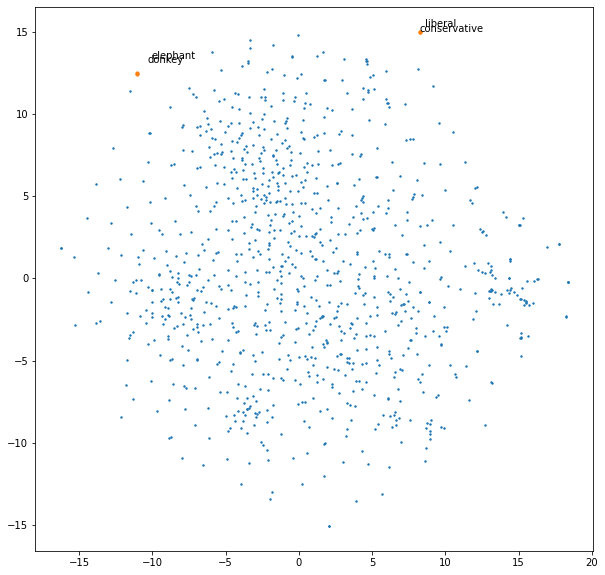

In [105]:
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word =
                          ['conservative', 'liberal', 
                           'donkey', 'elephant'])

It was expected that liberal and conservative are located close to each other (as they have, context related, a lot in common). This pair is located far from donkey and elephant, as they have not a lot in common with the liberal-conservative pair.

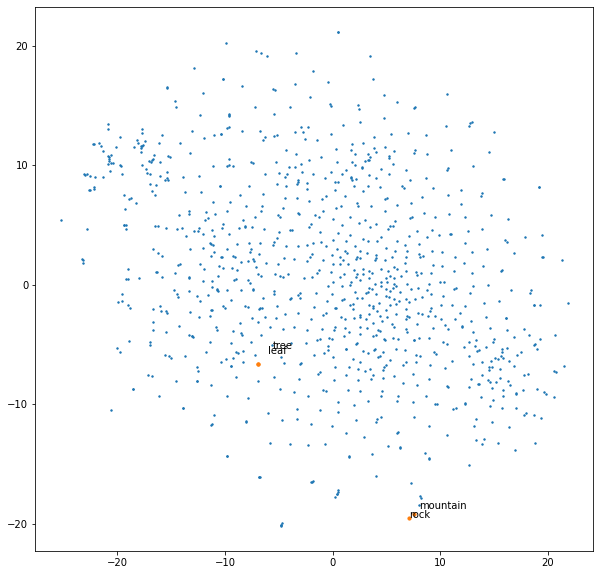

In [101]:
# Not expected
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word = 
                          ['rock', 'mountain', 
                           'leaf', 'tree'])

In the figure above the tree-leaf pair and the mountain-rock pairs are plotted. The words in each pair are located close to each other, as they are closely related. However, it was also expected that the pairs would be close to each other (so the 4 dots close to each other), as they all have a relation with nature. This is not the case here. This could be due to the fact that tree and leaf are more biology related, while mountain and rock are more geology related.

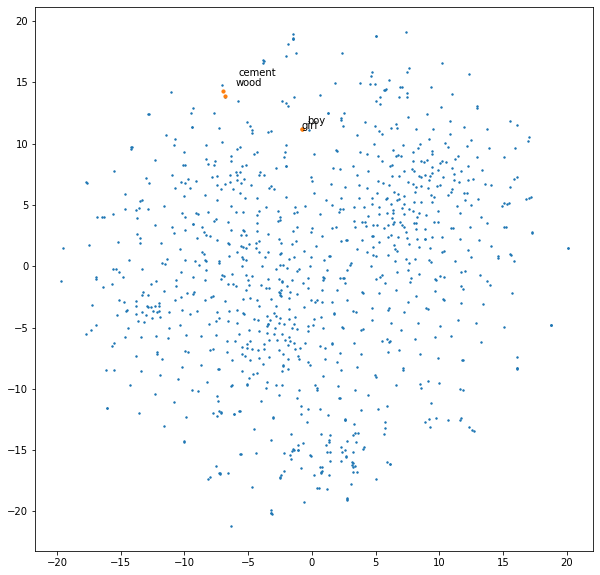

In [188]:
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word = 
                          ['girl', 'boy', 
                           'wood', 'cement'])

The figure above plots the words ('girl', 'boy', 'wood', 'cement'). It was expected that the words in each pair (girl-boy and wood-cement) are located closely to each other. The pairs itself are located somewhat further from each other, as gender has not a lot in common with construction material.

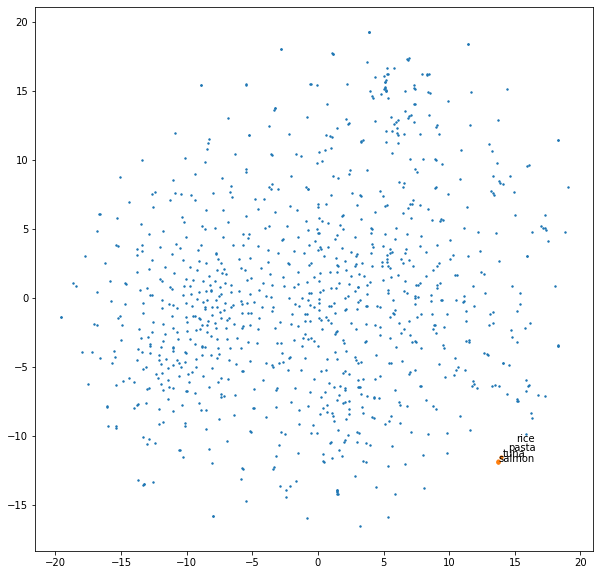

In [106]:
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word = 
                          ['salmon', 'tuna', 
                           'pasta', 'rice'])

The figure above plots the words ('salmon', 'tuna', 'pasta', 'rice'), they are located close to each other as they all have a relationship with food. So this result was expected.

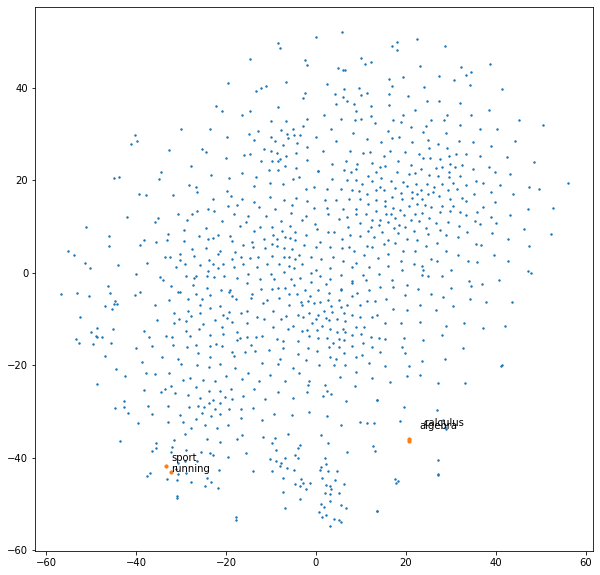

In [111]:
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word = 
                          ['running', 'sport', 
                           'algebra', 'calculus'])

The figure above plots the words ('running', 'sport', 'algebra', 'calculus'). The result was expected, as sport and running are closely related, but have not much in common with calculus and algebra.

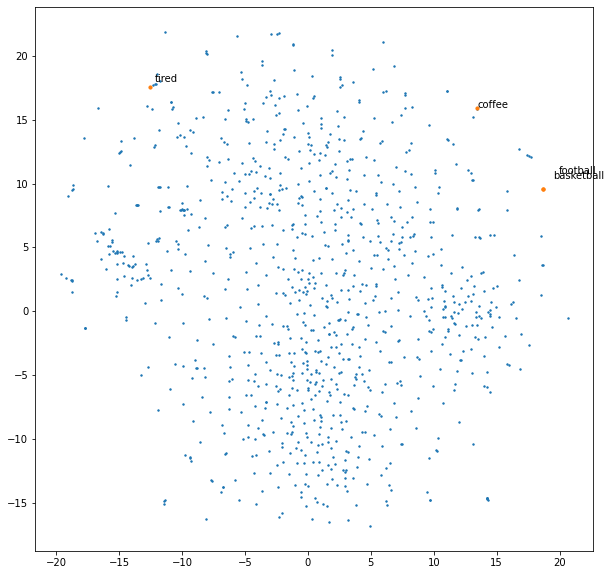

In [114]:
# Unexpected
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word = 
                          ['coffee', 'tired', 
                           'basketball', 'football'])

This is also an unexpected result, as it would be expected that coffee and tired would be located close to each other. An other strange result is that coffee is more closer to the sport related words (footbal and basketball) than tired, which is unexpected as "tired" is more closely related to sports. This could again be due to the fact that tired is used more in a clinical context (for example diseases).

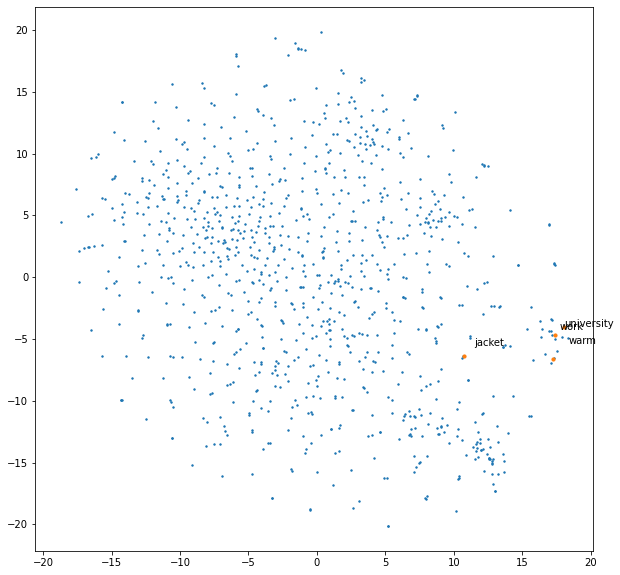

In [109]:
# Unexpected
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word = 
                          ['university', 'work', 
                           'jacket', 'warm'])

An other strange result is shown in the figure above, where the words ('university', 'work', 'jacket', 'warm') are plotted. It was expected that warm would be close to jacket, but in this case warm is more closer to university and work.

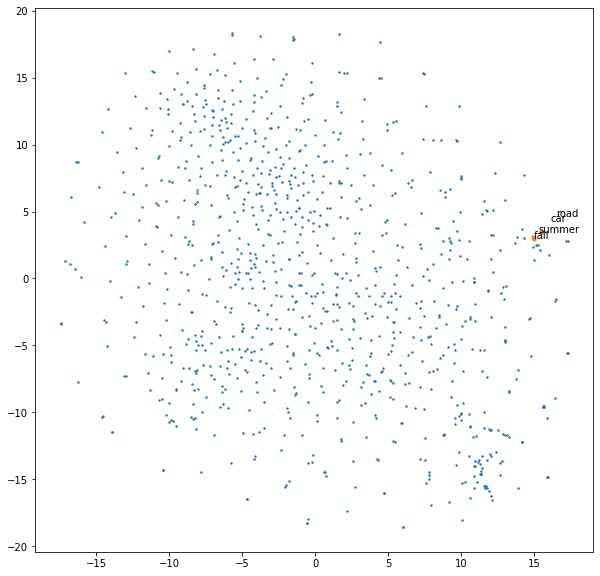

In [107]:
# Unexpected
%matplotlib inline
plt.figure(figsize=(10,10))
display_tsne_neighborhood(glove, 
                          input_word = 
                          ['fall', 'summer', 
                           'car', 'road'])

A last example of an unexpected result is shown in the figure above, where the words ('fall', 'summer', 'car', 'road') are plotted. It was not expected that these pairs would be located so close to each other. This could be due to the fact that (maybe) traveling (car, road) is related to summer and fall.

### Problem  3: Experiments with Musician Embeddings (15 points)


In this problem, we will use a collection of playlists obtained from [last.fm](http://last.fm). We treat each playlist as a document, and each artist in the playlist as a word. By feeding this dataset to word2vec, we will be able to learn artist embeddings.

#### Artist Embeddings

The following experiments will be done with the playlist data file `playlists.txt`. Each line in this file is a playlist. The integers on each line are unique artist identifiers, indicating which artists were in each playlist. The artists are in `artists.txt`.

The code below constructs artist embeddings with word2vec. The artist names are mapped to id numbers in the playlists; the code maps them back to display the names.

In [189]:
import gensim
from gensim.models import word2vec
import logging

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [190]:
playlists = word2vec.LineSentence('https://raw.githubusercontent.com/YData123/sds265-fa21/main/assignments/assn5/playlists.txt')
music_model = word2vec.Word2Vec(playlists, size=64, window=100, min_count=10)

In [191]:
music_model.wv['299']

array([-0.17171188, -0.45049667, -0.16295245, -0.57460386,  0.2024856 ,
        0.20512064,  1.0510069 ,  0.1852716 ,  0.18205431,  0.17455736,
        0.13594423, -0.90212   ,  0.7098693 , -0.5773354 ,  0.02970643,
       -0.497108  ,  0.8533337 ,  0.5674737 , -0.03432485,  0.01747533,
       -0.1117387 , -0.5105144 , -1.331387  ,  0.9953908 , -0.6912427 ,
       -0.7492859 ,  0.83271825, -0.5291535 , -0.3664959 , -0.08406557,
       -0.7244352 , -0.9969165 , -0.6758382 , -0.20932502, -0.20534389,
       -0.46966013,  0.12514688,  0.673193  , -1.4463036 ,  0.11042907,
        0.18037459,  0.6912738 ,  0.84413195, -0.43901137,  0.45834237,
        0.24254617,  0.3805396 ,  0.037363  , -0.34451577,  0.14464425,
        0.21135184,  0.6412077 ,  0.2881642 ,  0.09499145, -0.6346606 ,
        0.38231453, -0.37283567, -0.09148514, -0.28010884, -0.39587396,
       -0.61092186, -0.11742533,  0.20576921,  0.9448931 ], dtype=float32)

In [192]:
from urllib.request import urlopen 

artist = []
file = urlopen('https://raw.githubusercontent.com/YData123/sds265-fa21/main/assignments/assn5/artists.txt')
for line in file:
    art = line.decode("utf-8")
    artist.append(art.strip())

artist[0:10]

['Everette Harp',
 'Bishop Paul S. Morton & Aretha Franklin',
 'Frankie Ballard',
 'Herb Alpert',
 'Rod Stewart & Chaka Khan',
 'Scars On 45',
 'New Radicals',
 'Crosby, Stills & Nash',
 'Ledisi',
 'La Quinta Estacion']

In [193]:
id2name = {}
name2id = {}
for w in range(len(artist)):
    id2name["%s" % w] = artist[w]
    name2id[artist[w]] = "%s" % w

id2name[name2id['Elton John']]

'Elton John'

#### 3.1 Similar artists

Find the 5 closest artist embedding vectors to the artists "The Beatles", "Lady Gaga", and "Nirvana". Comment on the results.

In [194]:
# Don't change this function
def similar_artists(model, artist, n=5):
    id = name2id[artist]
    out = model.wv.most_similar(id, topn=n)

    print("artists similar to '%s'\n" % artist)
    for i in range(n) :
        name = id2name[out[i][0]]
        print("\t%s" % name)
        
similar_artists(music_model, 'Aerosmith')

artists similar to 'Aerosmith'

	Billy Idol
	The Jimi Hendrix Experience
	The Black Crowes
	Boston
	Def Leppard


In [121]:
# The Beatles

similar_artists(music_model, 'The Beatles')

artists similar to 'The Beatles'

	Steppenwolf
	The Electric Light Orchestra
	Creedence Clearwater Revival
	Grand Funk Railroad
	The Kinks


It makes sense that these artists are related to the Beatles, as they all correspond to the Psychedelic rock, Blues genre and they are all old groups.

In [123]:
# Lady Gaga

similar_artists(music_model, 'Lady Gaga')

artists similar to 'Lady Gaga'

	Bruno Mars
	Katy Perry
	Ke$ha
	Black Eyed Peas
	Jessie J


It makes sense that these artists are related to Lady Gaga, as they all correspond to the pop genre and they are all relatively recent artists.

In [122]:
# Nirvana

similar_artists(music_model, 'Nirvana')

artists similar to 'Nirvana'

	Stone Temple Pilots
	Temple Of The Dog
	Audioslave
	Faith No More
	Pearl Jam


It makes sense that these artists are related to the Nirvana, as they all correspond to the Rock, pop genre and are from the same time period.

#### 3.3 Visualize embeddings

Use the t-SNE dimensionality reduction technique to visualize the artist embeddings. After running t-SNE on the artist embeddings, try visualizing  "The Temptations" and "The Supremes" together. Find a few more examples that you think are interesting and include the plots in your write-up. Comment on your findings.

In [128]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# this functions computes and displays the 2-d t-SNE maps for a subset of the embedding vectors
# and displays them together with the points for a set of input words.

def display_tsne_artists(model, artists, nsample=1000, size1=2, size2=10, offset=5):
    
    arr = np.empty((0,64), dtype='f')

    # add the vector for each of the closest words to the array
    for a in range(len(artists)):
        id = name2id[artists[a]]
        arr = np.append(arr, np.array([model.wv[id]]), axis=0)

    voc = [w for w in model.wv.vocab]
    ids = np.random.choice(range(len(voc)), size=nsample, replace=False)
    for w in ids:
        wrd_vector = model.wv[voc[w]]
        arr = np.append(arr, np.array([wrd_vector]), axis=0)
        
    # find tsne coords for 2 dimensions
    tsne = TSNE(n_components=2, random_state=0)
    np.set_printoptions(suppress=True)
    Y = tsne.fit_transform(arr)

    x_coord = Y[:, 0]
    y_coord = Y[:, 1]
    # display scatter plot
    size=2
    plt.scatter(x_coord, y_coord, s=size1)
    plt.scatter(x_coord[0:len(artists)], y_coord[0:len(artists)],s=size2)
    
    # label the input words
    for w in range(len(artists)):
        plt.annotate(artists[w], xy=(x_coord[w],y_coord[w]), \
                     xytext=(w*offset,w*offset), textcoords='offset points')
    plt.show()

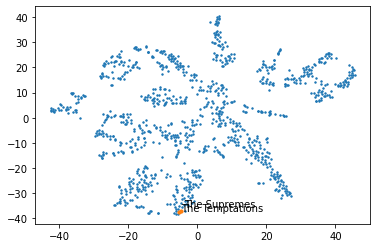

In [129]:
display_tsne_artists(music_model, 
                     ["The Temptations", "The Supremes"])

tSNE has created an embedding where clusters can definitely be recognized. These clusters probably correspond to different genres or time periods. The Temptations and The Supremes are located close to each other in the embedding, as they are both R&B/Soul-artists. 

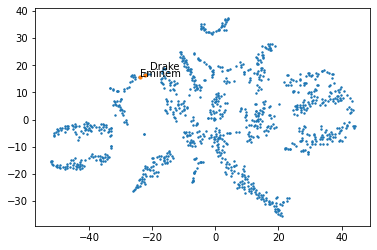

In [132]:
display_tsne_artists(music_model, 
                     ["Eminem", "Drake"])

Eminem and Drake are located close to each other in the embedding, as they are both rappers with a similar style of music.

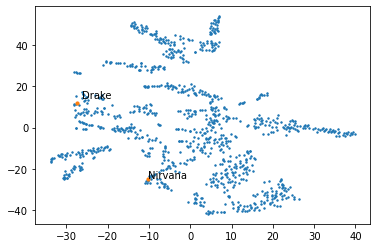

In [136]:
display_tsne_artists(music_model, 
                     ["Nirvana", "Drake"])

Nirvana and Drake are not located close to each other, as Nirvana is a rock/pop group and Drake is a hip hop artist.

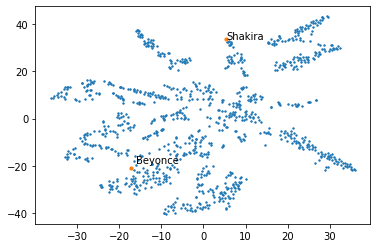

In [195]:
display_tsne_artists(music_model, 
                     ["Shakira", "Beyonce"])

To finalize, an unexpected result is shown. It was expected that Beyonce and Shakira would be located close to each other, as they are both pop artist from the same time period. The reason why they are not located close to each other is maybe because of a difference in their singing style and therefore people don't tend to put both singers in the same playlist.